In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

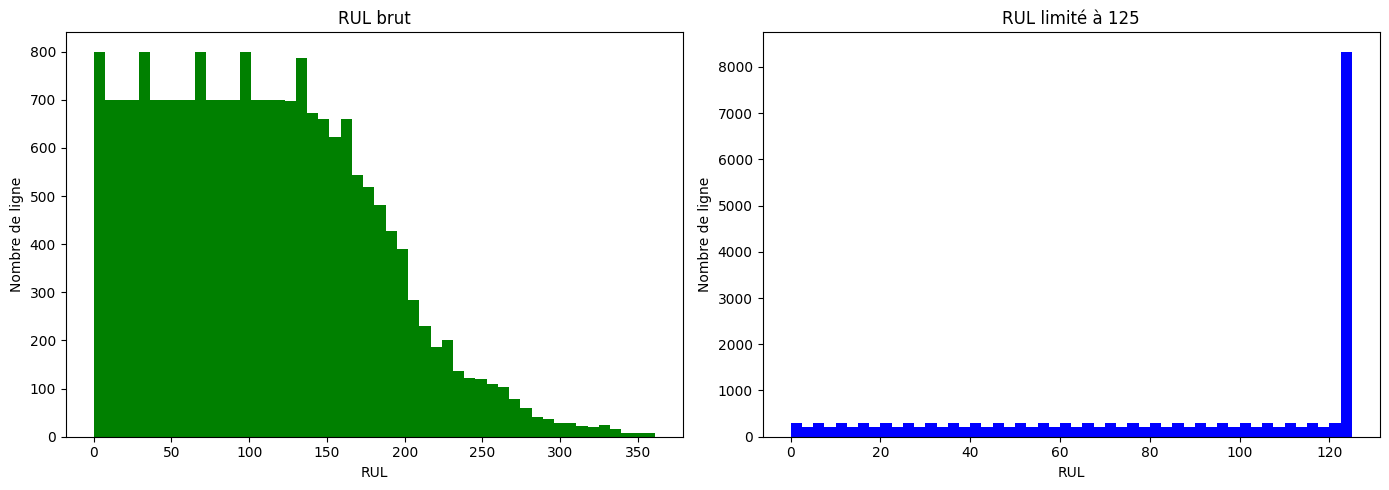

In [16]:
DataBase = sqlite3.connect("Base_de_donnée_des_test.db")
df1 = pd.read_sql("""SELECT * FROM Train WHERE "file origin" = "FD001" """,DataBase)
df2 = pd.read_sql("SELECT * FROM Train_clean_FD001",DataBase)

df1["cycle max"] = df1.groupby(["unit number","file origin"])["time, in cycles"].transform("max")
df1["RUL_brut"] = df1["cycle max"] - df1["time, in cycles"]
df1 = df1.drop("cycle max",axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df1["RUL_brut"],bins=50,color="green")
axes[0].set_title("RUL brut")
axes[0].set_xlabel("RUL")
axes[0].set_ylabel("Nombre de ligne")


axes[1].hist(df2["RUL"], bins=50, color="blue")
axes[1].set_title("RUL limité à 125")
axes[1].set_xlabel("RUL")
axes[1].set_ylabel("Nombre de ligne")

plt.tight_layout()
plt.show()

DataBase.close()

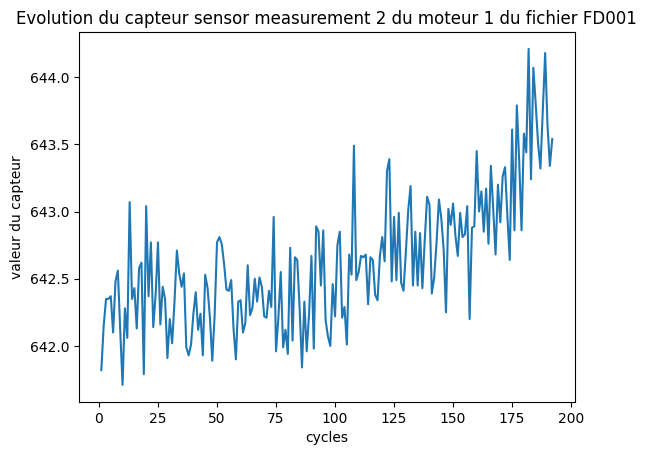

In [9]:
DataBase = sqlite3.connect("Base_de_donnée_des_test.db")
df = pd.read_sql("""SELECT * FROM Train_clean_FD001 WHERE "unit number" = 1""",DataBase)
DataBase.close()

plt.plot(df["time, in cycles"], df["sensor measurement 2"])
plt.xlabel("cycles")
plt.ylabel("valeur du capteur")
plt.title("Evolution du capteur sensor measurement 2 du moteur 1 du fichier FD001")
plt.show()

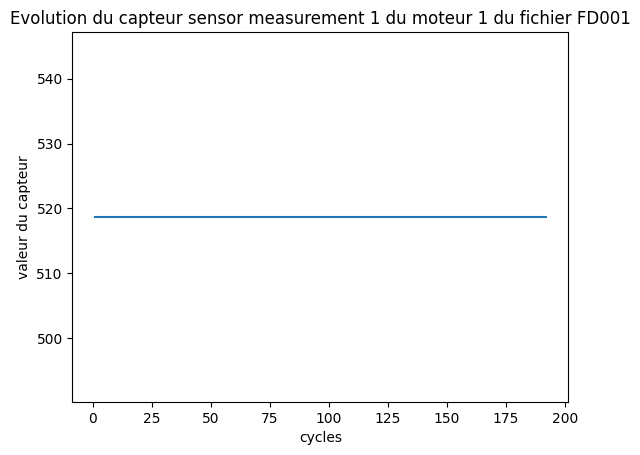

In [10]:
DataBase = sqlite3.connect("Base_de_donnée_des_test.db")
df = pd.read_sql("""SELECT * FROM Train WHERE "unit number" = 1 AND "file origin" = "FD001" """,DataBase)
DataBase.close()

plt.plot(df["time, in cycles"], df["sensor measurement 1"])
plt.xlabel("cycles")
plt.ylabel("valeur du capteur")
plt.title("Evolution du capteur sensor measurement 1 du moteur 1 du fichier FD001")
plt.show()

['sensor measurement 2', 'sensor measurement 3', 'sensor measurement 4', 'sensor measurement 7', 'sensor measurement 8', 'sensor measurement 9', 'sensor measurement 11', 'sensor measurement 12', 'sensor measurement 13', 'sensor measurement 14', 'sensor measurement 15', 'sensor measurement 17', 'sensor measurement 20', 'sensor measurement 21']


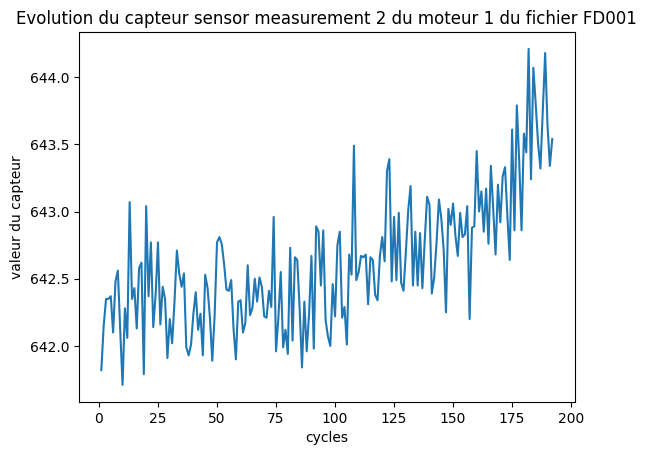

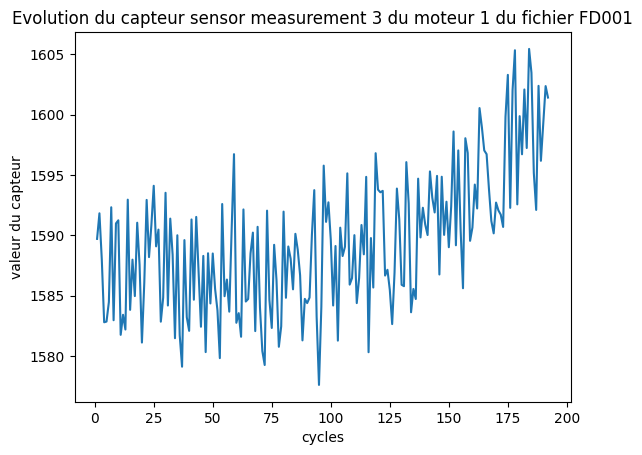

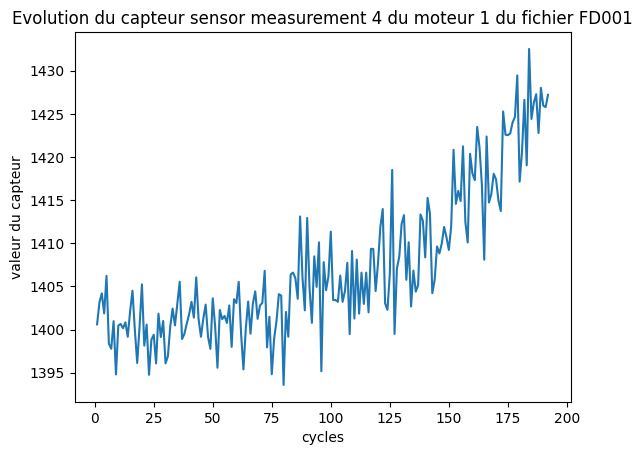

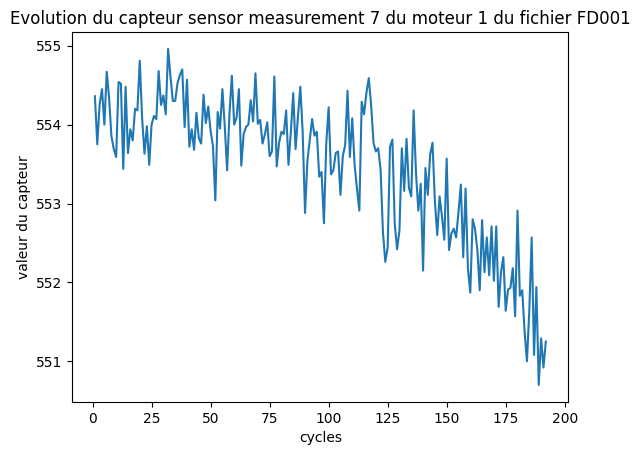

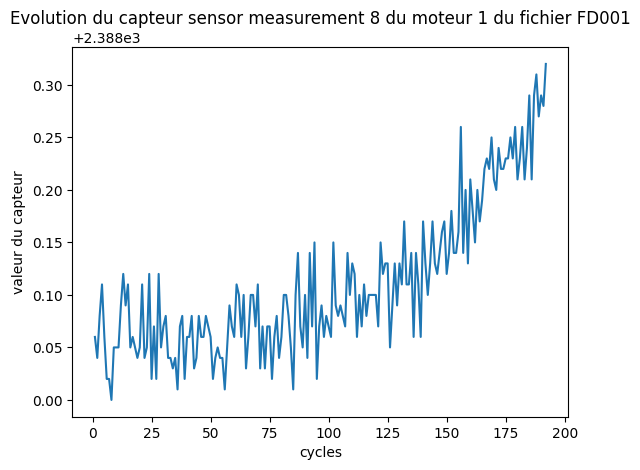

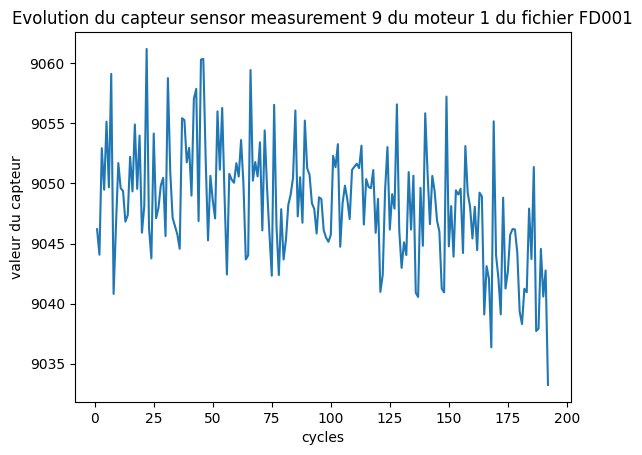

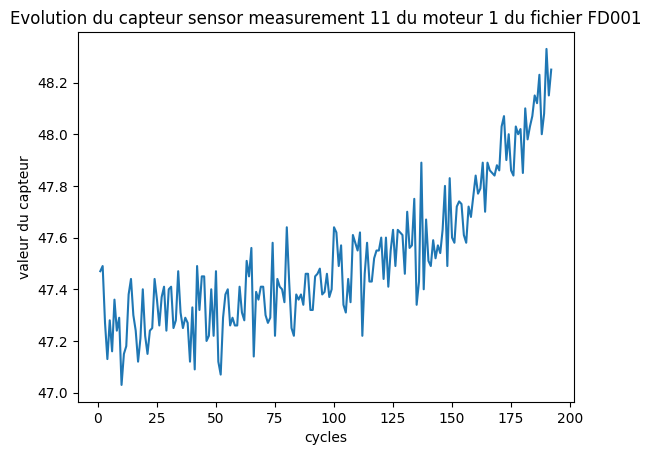

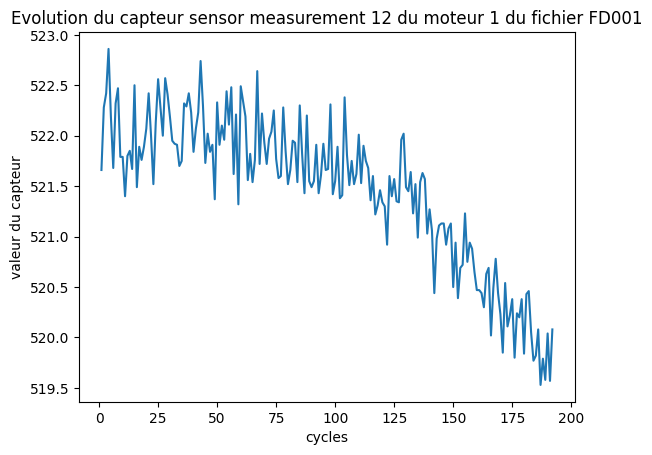

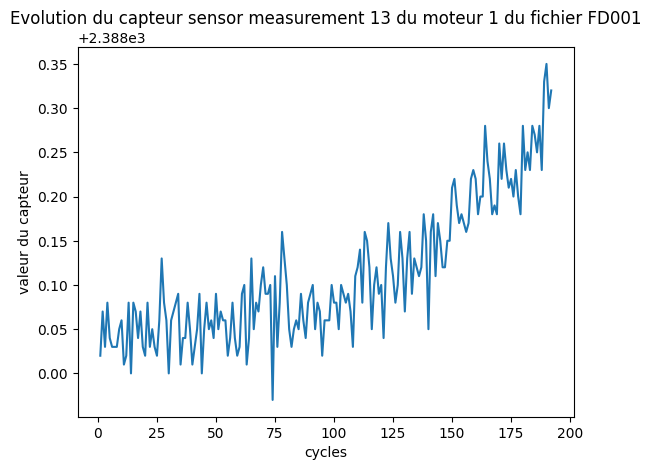

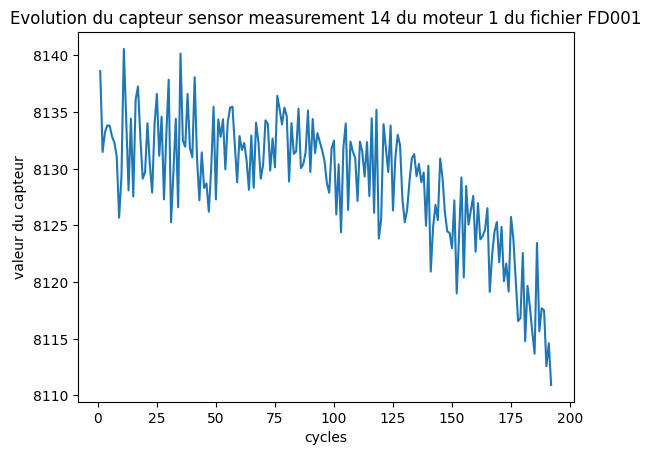

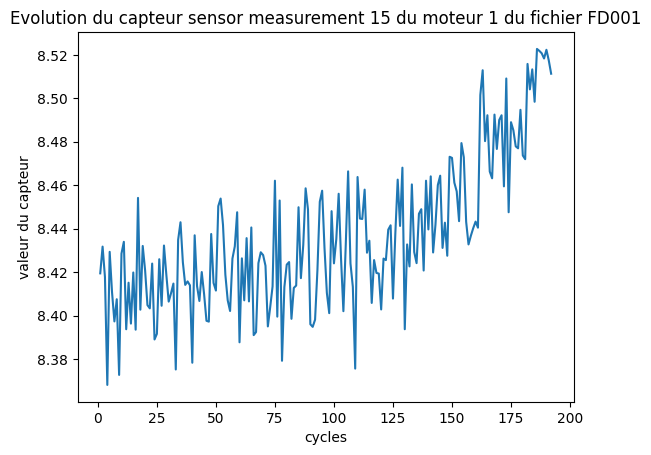

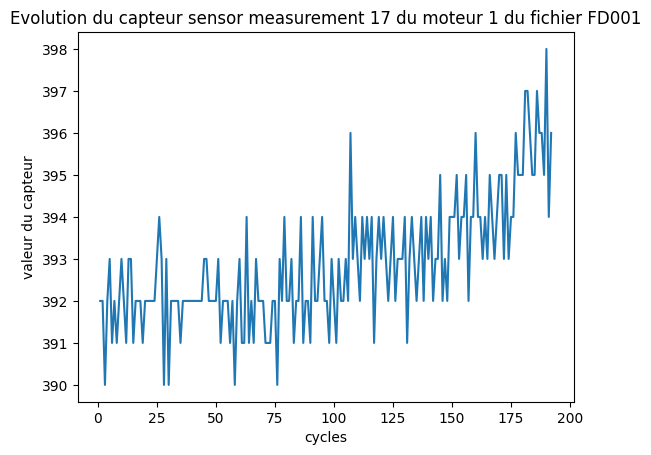

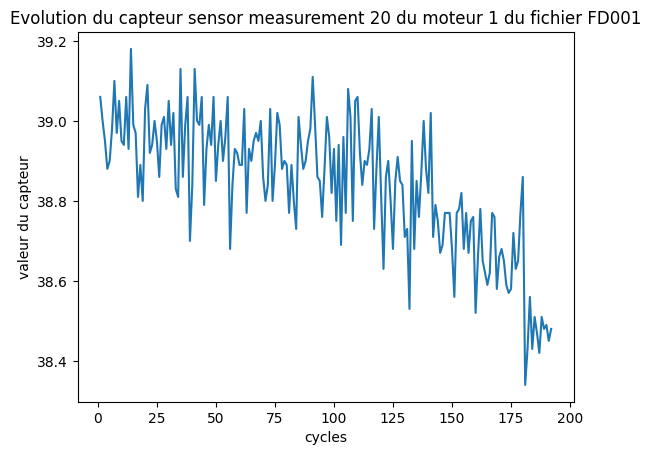

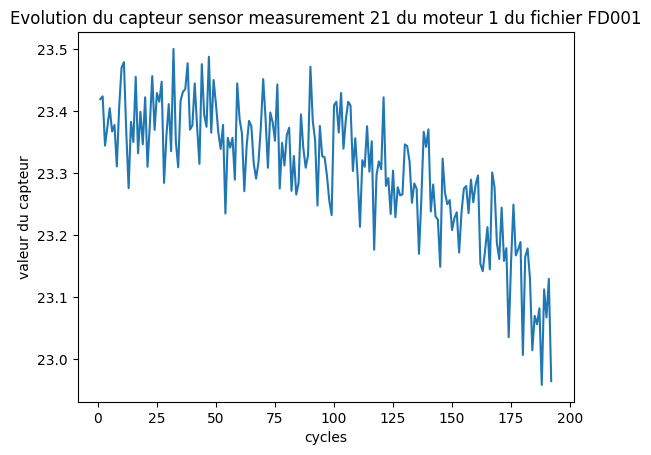

In [11]:
DataBase = sqlite3.connect("Base_de_donnée_des_test.db")
df = pd.read_sql("""SELECT * FROM Train_clean_FD001 WHERE "unit number" = 1""",DataBase)
DataBase.close()

colonne = list(df.columns)
suppr = ["unit number","time, in cycles","file origin","RUL"]
for i in range(1,4):
    suppr.append(f"operationnal setting {i}")
for element in suppr:
    colonne.remove(element)
print(colonne)
for capteur in colonne:

    plt.plot(df["time, in cycles"], df[capteur],label=capteur)
    plt.xlabel("cycles")
    plt.ylabel("valeur du capteur")
    plt.title(f"Evolution du capteur {capteur} du moteur 1 du fichier FD001")
    plt.show()


unit number
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: time, in cycles, Length: 100, dtype: int64


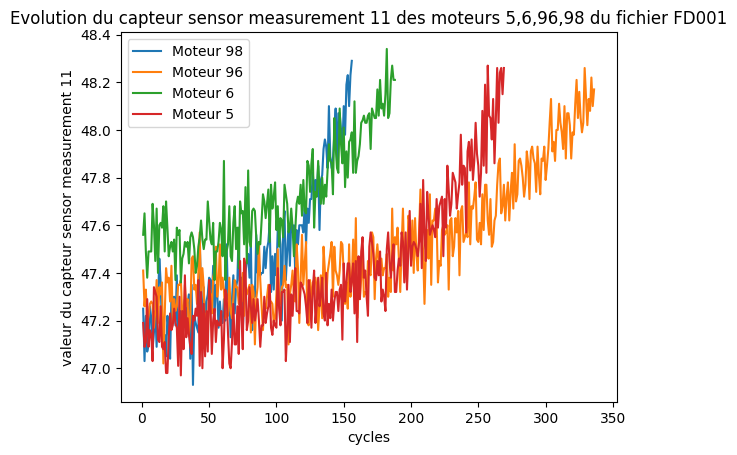

In [21]:
DataBase = sqlite3.connect("Base_de_donnée_des_test.db")
df = pd.read_sql("SELECT * FROM Train_clean_FD001",DataBase)
print(df.groupby("unit number")["time, in cycles"].max())

for i in (98,96,6,5):
    plt.plot(df[df["unit number"]==i]["time, in cycles"], df[df["unit number"]==i]["sensor measurement 11"],label=f"Moteur {i}")

plt.xlabel("cycles")
plt.ylabel("valeur du capteur sensor measurement 11")
plt.title(f"Evolution du capteur sensor measurement 11 des moteurs 5,6,96,98 du fichier FD001")
plt.legend()
plt.savefig("images/degradation_capteur11.png",bbox_inches="tight")
plt.show()

DataBase.close()

unit number
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: time, in cycles, Length: 100, dtype: int64


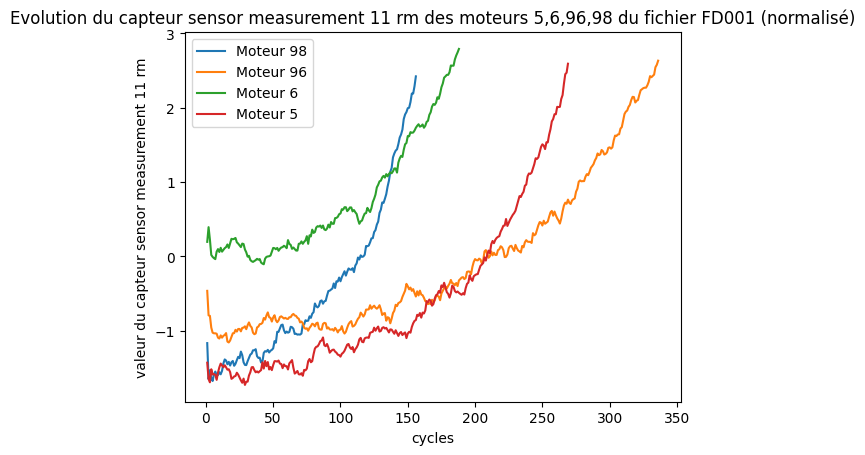

In [20]:
DataBase = sqlite3.connect("Base_de_donnée_des_test.db")
df = pd.read_sql("SELECT * FROM Train_Normalisé_FD001",DataBase)
print(df.groupby("unit number")["time, in cycles"].max())

for i in (98,96,6,5):
    plt.plot(df[df["unit number"]==i]["time, in cycles"], df[df["unit number"]==i]["sensor measurement 11 rm"],label=f"Moteur {i}")

plt.xlabel("cycles")
plt.ylabel("valeur du capteur sensor measurement 11 rm")
plt.title(f"Evolution du capteur sensor measurement 11 rm des moteurs 5,6,96,98 du fichier FD001 (normalisé)")
plt.legend()
plt.savefig("images/degradation_capteur11_normalise.png",bbox_inches="tight")
plt.show()

DataBase.close()

unit number
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: time, in cycles, Length: 100, dtype: int64


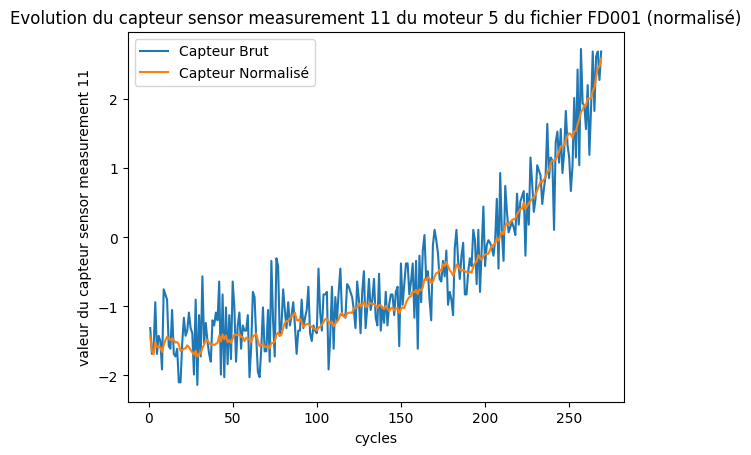

In [8]:
DataBase = sqlite3.connect("Base_de_donnée_des_test.db")
df = pd.read_sql("SELECT * FROM Train_Normalisé_FD001",DataBase)
print(df.groupby("unit number")["time, in cycles"].max())

plt.plot(df[df["unit number"]==5]["time, in cycles"], df[df["unit number"]==5]["sensor measurement 11"],label=f"Capteur Brut")
plt.plot(df[df["unit number"]==5]["time, in cycles"], df[df["unit number"]==5]["sensor measurement 11 rm"],label=f"Capteur Normalisé")

plt.xlabel("cycles")
plt.ylabel("valeur du capteur sensor measurement 11")
plt.title(f"Evolution du capteur sensor measurement 11 du moteur 5 du fichier FD001 (normalisé)")
plt.legend()
plt.savefig("images/degradation_capteur11_moteur11_comparatif.png",bbox_inches="tight")
plt.show()

DataBase.close()

sensor measurement 11   -0.775230
sensor measurement 4    -0.757157
sensor measurement 12    0.748870
sensor measurement 7     0.733021
sensor measurement 15   -0.720858
sensor measurement 21    0.707334
sensor measurement 20    0.704626
sensor measurement 17   -0.680829
sensor measurement 2    -0.678458
sensor measurement 3    -0.655030
sensor measurement 8    -0.624568
sensor measurement 13   -0.624034
sensor measurement 9    -0.462151
sensor measurement 14   -0.369753
Name: RUL, dtype: float64


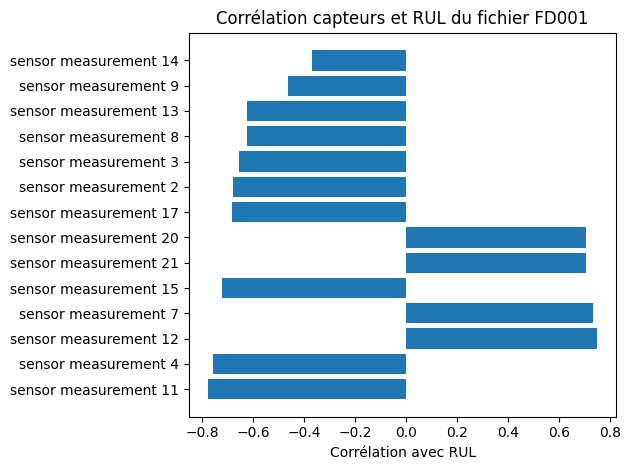

In [7]:
DataBase = sqlite3.connect("Base_de_donnée_des_test.db")
df = pd.read_sql("SELECT * FROM Train_clean_FD001",DataBase)
colonne_capteur = list(df.filter(like='sensor measurement').columns)
correlation_RUL = df[colonne_capteur + ["RUL"]].corr()["RUL"].drop("RUL",axis=0)
#Correlation de chaque capteur avec le RUL
correlation_RUL.sort_values(key=abs,ascending=False,inplace=True)
print(correlation_RUL)
plt.barh(correlation_RUL.index,correlation_RUL.values)
plt.xlabel("Corrélation avec RUL")
plt.title("Corrélation capteurs et RUL du fichier FD001")
plt.tight_layout()
plt.savefig("images/correlation_capteur_RUL_FDOO1.png",bbox_inches="tight")
plt.show()
DataBase.close()